# 1주차 · 사람의 단서에서 MNIST 분류까지
2026-09-16 개정. **이미지 분류/객체 인식 구분 → 사람의 단서 → CNN 용어 → 실제 MNIST** 흐름입니다.

이 노트북은 숫자 한 장을 0–9 중 하나로 고릅니다. 사진 안의 여러 숫자의 위치 상자를 찾는 검출기는 아닙니다.
객체 인식은 넓은 표현이므로 분류·검출·분할 중 어떤 출력을 요구하는지 함께 말하세요.

| 구간 | PDF | 할 일 | 권장 시간 |
|---|---|---|---|
| 0–2 | 3–10, 19–22쪽 | 단서 관찰·픽셀·라벨 | 10분 |
| 3–4 | 11–17, 23–24쪽 | 필터 계산·모델 크기 | 10분 |
| 5–7 | 25–27쪽 | 학습·예측·오류 관찰 | 15분 |
| 8–9 | 확장 | 특징 맵·변환·보고서 | 10–15분 |

전체 실습은 45–50분을 따로 배정합니다. 90분 PDF 수업에서 전부 추가하지 않습니다.
짧게 시연하려면 준비·학습을 미리 실행하고 6–7의 예측과 오류를 읽으세요.

Colab에서 위부터 실행합니다. torch·numpy·matplotlib를 사용하고 **CPU**로 계산합니다.
처음에는 실제 MNIST 압축 파일 약11MB를 다운로드하므로 인터넷 연결이 필요합니다. 이미 있으면 무결성을 확인하고 재사용합니다.
노트북 하나만으로 실행되며 추가 Python 파일·이전 주차 실행 상태는 필요 없습니다.
로컬에 패키지가 없으면 `%pip install torch numpy matplotlib`를 별도 셀에서 실행하세요.

실제 관측 출력과 그림이 저장되어 있습니다. 서로 다른 환경에서 성능·시간이 같다는 보장은 아닙니다.

## 0. 도구 준비
다음 보조 함수 셀은 실행만 합니다. 데이터 로더·작은 CNN·그림 함수가 들어 있습니다.
사람의 “질문/지도/피드백”이라는 비유가 실제로는 가중치·배열·손실 계산이라는 점을 기억하세요.

In [1]:
"""MNIST teaching experiment; this module is embedded in the standalone notebook."""
from pathlib import Path
import os, gzip, hashlib, struct, urllib.request, json, time, copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
from torch import nn
import torch.nn.functional as F

FILES = {
 'train-images-idx3-ubyte.gz': 'f68b3c2dcbeaaa9fbdd348bbdeb94873',
 'train-labels-idx1-ubyte.gz': 'd53e105ee54ea40749a09fcbcd1e9432',
 't10k-images-idx3-ubyte.gz': '9fb629c4189551a2d022fa330f9573f3',
 't10k-labels-idx1-ubyte.gz': 'ec29112dd5afa0611ce80d1b7f02629c'}

def read_mnist():
    # Same MNIST mirror/checksums published in torchvision.datasets.MNIST.
    cache = Path(os.environ.get('AIM_MNIST_CACHE','data/MNIST/raw'))
    cache.mkdir(parents=True,exist_ok=True)
    arrays=[]
    for name,digest in FILES.items():
        path=cache/name
        if not path.exists():
            print('Downloading',name,flush=True)
            url='https://ossci-datasets.s3.amazonaws.com/mnist/'+name
            with urllib.request.urlopen(url,timeout=60) as source:
                payload=source.read()
            assert hashlib.md5(payload).hexdigest()==digest, 'MNIST download checksum mismatch'
            path.write_bytes(payload)
        packed=path.read_bytes()
        assert hashlib.md5(packed).hexdigest()==digest, f'Corrupt cache: {path}; remove only this file and retry.'
        raw=gzip.decompress(packed)
        magic,count=struct.unpack('>II',raw[:8])
        if magic==2051:
            rows,cols=struct.unpack('>II',raw[8:16]);assert (rows,cols)==(28,28)
            array=np.frombuffer(raw, dtype=np.uint8,offset=16).copy().reshape(count,28,28)
        else:
            assert magic==2049
            array=np.frombuffer(raw,dtype=np.uint8,offset=8).copy()
            assert len(array)==count
        arrays.append(torch.from_numpy(array))
    assert len(arrays[0])==60000 and len(arrays[2])==10000
    return arrays

def prepare_data(seed=17):
    train_images,train_labels,test_images,test_labels=read_mnist()
    rng=torch.Generator().manual_seed(seed)
    ti=[];vi=[];si=[]
    for label in range(10):
        ix=torch.where(train_labels==label)[0]
        ix=ix[torch.randperm(len(ix),generator=rng)]
        ti.append(ix[:600]);vi.append(ix[600:700])
        ix=torch.where(test_labels==label)[0]
        si.append(ix[torch.randperm(len(ix),generator=rng)[:100]])
    ti,vi,si=map(torch.cat,(ti,vi,si))
    assert not set(ti.tolist()) & set(vi.tolist())
    def x(image,index):return image[index].unsqueeze(1).float()/255
    return dict(x_train=x(train_images,ti),y_train=train_labels[ti].long(),
        x_val=x(train_images,vi),y_val=train_labels[vi].long(),
        x_test=x(test_images,si),y_test=test_labels[si].long(),
        train_indices=ti,val_indices=vi,test_indices=si)

class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features=nn.Sequential(nn.Conv2d(1,8,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(8,16,3,padding=1),nn.ReLU(),nn.MaxPool2d(2))
        self.classifier=nn.Linear(16*7*7,10)
    def forward(self,x):return self.classifier(self.features(x).flatten(1))

@torch.no_grad()
def evaluate_digit(model,x,y):
    model.eval()
    logits=torch.cat([model(batch) for batch in x.split(256)])
    pred=logits.argmax(1)
    cm=torch.bincount(y*10+pred,minlength=100).reshape(10,10)
    return dict(accuracy=float((pred==y).float().mean()),ce=float(F.cross_entropy(logits,y)),
        logits=logits,pred=pred,confusion=cm)

def fit_digit(data,epochs=6,seed=17):
    torch.set_num_threads(min(4,torch.get_num_threads()))
    torch.manual_seed(seed)
    model=DigitCNN();initial=copy.deepcopy(model.state_dict())
    optimizer=torch.optim.Adam(model.parameters(),lr=.003)
    order=torch.Generator().manual_seed(seed+1)
    history={'train_ce':[],'val_ce':[],'val_accuracy':[]}
    start=time.perf_counter()
    for epoch in range(epochs):
        model.train();total=0.
        for ix in torch.randperm(len(data['y_train']),generator=order).split(128):
            optimizer.zero_grad()
            loss=F.cross_entropy(model(data['x_train'][ix]),data['y_train'][ix])
            assert torch.isfinite(loss)
            loss.backward();optimizer.step()
            total+=float(loss.detach())*len(ix)
        val=evaluate_digit(model,data['x_val'],data['y_val'])
        history['train_ce'].append(total/len(data['y_train']))
        history['val_ce'].append(val['ce']);history['val_accuracy'].append(val['accuracy'])
        print(f"epoch {epoch+1}/{epochs}: train CE {history['train_ce'][-1]:.3f}, val accuracy {val['accuracy']:.3f}")
    print(f'Training: {time.perf_counter()-start:.1f}s / CPU')
    # The final epoch is fixed in advance; test does not select a checkpoint.
    return model,history,initial

def style_figures():
    plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'figure.dpi':130,
        'figure.facecolor':'#f4f2e9','axes.facecolor':'#f4f2e9','axes.spines.top':False,
        'axes.spines.right':False,'axes.prop_cycle':plt.cycler(color=['#087e76','#e9643d'])})

def sample_figure(data):
    fig,axs=plt.subplots(3,10,figsize=(10,3.5))
    indices=[]
    for label in range(10):
        ids=torch.where(data['y_test']==label)[0][:3];indices.extend(ids.tolist())
        for row,i in enumerate(ids):
            axs[row,label].imshow(data['x_test'][i,0],cmap='gray',vmin=0,vmax=1)
            axs[row,label].axis('off')
            if row==0:axs[row,label].set_title(str(label),fontsize=16)
    fig.tight_layout(pad=.5)
    return fig

def pixels_figure(data,index=700):
    img=data['x_test'][index,0]
    fig,axs=plt.subplots(1,2,figsize=(7,3.7))
    axs[0].imshow(img,cmap='gray',vmin=0,vmax=1)
    axs[0].add_patch(Rectangle((9.5,9.5),6,6,fill=False,edgecolor='#e9643d',linewidth=2))
    axs[0].set_title('28 x 28 / 1 channel');axs[0].axis('off')
    patch=(img[10:16,10:16]*255).round().int()
    axs[1].imshow(patch,cmap='gray',vmin=0,vmax=255)
    for (r,c),v in np.ndenumerate(patch.numpy()):
        axs[1].text(c,r,str(v),ha='center',va='center',fontsize=8,color='black' if v>120 else 'white')
    axs[1].set_title('A 6 x 6 patch / 0...255');axs[1].axis('off')
    fig.tight_layout();return fig

def manual_filter_figure(data,index=700):
    x=data['x_test'][index:index+1]
    k=torch.tensor([[-1.,0.,1.]]*3)
    maps=F.conv2d(x,torch.stack([k,k.T])[:,None],padding=1)
    fig,axs=plt.subplots(1,3,figsize=(9,3.3))
    axs[0].imshow(x[0,0],cmap='gray',vmin=0,vmax=1);axs[0].set_title('Actual MNIST input')
    for ax,m,title in zip(axs[1:],maps[0],['Left-right difference','Top-bottom difference']):
        ax.imshow(m,cmap='RdBu_r',vmin=-3,vmax=3);ax.set_title(title,fontsize=11)
    for ax in axs:ax.axis('off')
    fig.tight_layout();return fig

def history_figure(history):
    fig,axs=plt.subplots(1,2,figsize=(8,3.6));ep=np.arange(1,len(history['train_ce'])+1)
    axs[0].plot(ep,history['train_ce'],'o-',label='train');axs[0].plot(ep,history['val_ce'],'o-',label='validation')
    axs[0].set(xlabel='epoch',ylabel='cross entropy');axs[0].legend(fontsize=9)
    axs[1].plot(ep,history['val_accuracy'],'o-');axs[1].set(xlabel='epoch',ylabel='validation accuracy',ylim=(.8,1))
    fig.tight_layout();return fig

def feature_figure(model,data,index=700):
    with torch.no_grad():maps=F.relu(model.features[0](data['x_test'][index:index+1]))[0]
    fig,axs=plt.subplots(2,4,figsize=(7,4));limit=max(float(maps.max()),1e-6)
    for i,ax in enumerate(axs.flat):
        ax.imshow(maps[i],cmap='magma',vmin=0,vmax=limit);ax.set_title(f'channel {i}');ax.axis('off')
    fig.tight_layout();return fig

def errors_figure(data,result):
    ids=torch.where(result['pred']!=data['y_test'])[0][:6]
    wrong=True
    if not len(ids):ids=torch.arange(6);wrong=False
    fig,axs=plt.subplots(2,3,figsize=(6,4.5))
    for ax in axs.flat:ax.axis('off')
    for ax,i in zip(axs.flat,ids):
        ax.imshow(data['x_test'][i,0],cmap='gray',vmin=0,vmax=1)
        ax.set_title(f"label {int(data['y_test'][i])} / pred {int(result['pred'][i])}",fontsize=11,color='#b34429')
    fig.tight_layout();return fig,ids,wrong

def prediction_figure(data,result,index=700):
    fig,axs=plt.subplots(1,2,figsize=(7,3.5))
    axs[0].imshow(data['x_test'][index,0],cmap='gray',vmin=0,vmax=1);axs[0].axis('off')
    axs[0].set_title(f"label {int(data['y_test'][index])} / pred {int(result['pred'][index])}")
    probs=result['logits'][index].softmax(0).numpy()
    axs[1].bar(np.arange(10),probs,color='#087e76');axs[1].set(xticks=range(10),ylim=(0,1),xlabel='digit class',ylabel='softmax')
    fig.tight_layout();return fig

def experiment_metrics(data,model,history,result,epochs,seed):
    return dict(dataset='MNIST',seed=seed,epochs=epochs,device='cpu',torch=torch.__version__,
        train_n=len(data['y_train']),val_n=len(data['y_val']),test_n=len(data['y_test']),
        parameters=sum(p.numel() for p in model.parameters()),accuracy=result['accuracy'],ce=result['ce'],
        confusion=result['confusion'].tolist(),history=history,
        test_indices=data['test_indices'].tolist())

def export_assets(target,data,model,history,result,epochs=6,seed=17):
    target=Path(target);target.mkdir(parents=True,exist_ok=True);style_figures()
    error_fig,ids,wrong=errors_figure(data,result)
    figures={'samples':sample_figure(data),'pixels':pixels_figure(data),
        'filters':manual_filter_figure(data),'learning':history_figure(history),
        'features':feature_figure(model,data),'prediction':prediction_figure(data,result),'errors':error_fig}
    for name,fig in figures.items():
        fig.savefig(target/f'mnist_{name}.png',dpi=190,bbox_inches='tight');plt.close(fig)
    metrics=experiment_metrics(data,model,history,result,epochs,seed)
    metrics['error_example_indices']=data['test_indices'][ids].tolist()
    metrics['error_examples_are_errors']=wrong
    (target/'mnist_metrics.json').write_text(json.dumps(metrics,ensure_ascii=False,indent=2),encoding='utf-8')
    return metrics

In [2]:
SEED = 17
EPOCHS = 6  # test를 보기 전에 결정합니다.
style_figures()
torch.set_num_threads(min(4,torch.get_num_threads()))
print('PyTorch:',torch.__version__,'/ device: CPU')

PyTorch: 2.14.0+cpu / device: CPU


## 1. 서로 다른 글씨를 같은 숫자로 묶기
**먼저 예상:** 7을 알아볼 때 어떤 획과 관계를 보나요? 두께·기울기가 달라도 무시할 수 있는 차이는 무엇인가요?
공식 MNIST는 train60,000/test10,000입니다. 여기서는 클래스마다 train600·val100·test100장씩 선택합니다.
train/val은 공식 train 안에서 서로 겹치지 않습니다. 마지막 평가용 test1,000장은 학습에 사용하지 않습니다.

수업용 train/val/test: 6000 1000 1000


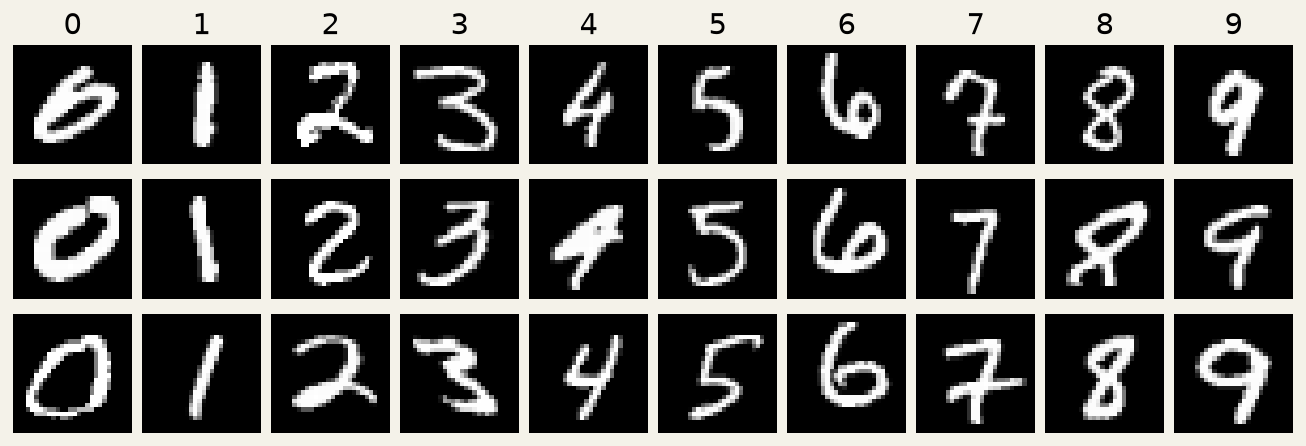

In [3]:
data = prepare_data(SEED)
print('수업용 train/val/test:',len(data['y_train']),len(data['y_val']),len(data['y_test']))
sample_figure(data); plt.show()

**관찰:** 한 열은 같은 라벨의 실제 표본입니다. 모양이 같은 픽셀 배열인지, 다른 모습에서 비슷한 구조를 읽는지 말해 보세요.
“사람은 항상 정답”이라는 가정 없이 애매한 글씨도 찾아 봅니다.

## 2. 그림과 숫자 배열의 연결
**픽셀**은 한 위치의 밝기, **라벨**은 맞혀야 할 범주입니다. [1,28,28]의 1은 흑백 채널 하나이며 클래스 수는10입니다.

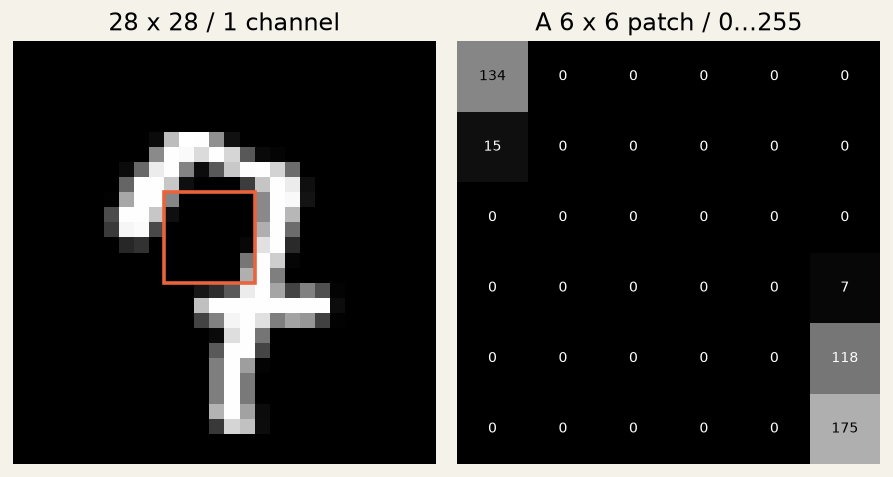

입력 shape: (1, 28, 28) 정답 label: 7
원래 픽셀0~255를 /255하여 입력0~1로 변환했습니다.


In [4]:
DIGIT = 7  # 0~9. 변경 후 이 셀부터 관련 그림 셀을 다시 실행합니다.
assert DIGIT in range(10)
SAMPLE = int(torch.where(data['y_test']==DIGIT)[0][0])
pixels_figure(data,SAMPLE); plt.show()
print('입력 shape:',tuple(data['x_test'][SAMPLE].shape),'정답 label:',int(data['y_test'][SAMPLE]))
print('원래 픽셀0~255를 /255하여 입력0~1로 변환했습니다.')

## 3. 필터라는 작은 질문을 실제로 계산
먼저 단순한 5×5 입력으로 확인합니다. 각 행이 [−1,0,1]인 필터는 오른쪽에서 왼쪽을 뺍니다.
**예상:** 경계가 있는 창과 모두 밝은 창의 반응은 어떻게 다를까요? 반응은 클래스 확률이 아닙니다.

In [5]:
toy=torch.tensor([[0,0,1,1,1]]*5,dtype=torch.float32)
kernel=torch.tensor([[-1,0,1]]*3,dtype=torch.float32)
COL=0  # 0→2로 변경하고 이 셀만 실행해 보세요.
assert COL in (0,1,2)
patch=toy[:3,COL:COL+3]
response=F.conv2d(toy[None,None],kernel[None,None])[0,0]
print('패치:',patch.tolist(),'\n원소별 곱의 합:',float((patch*kernel).sum()))
print('특징 맵:',response.tolist())
assert torch.isclose((patch*kernel).sum(),response[0,COL])
assert torch.equal(response,torch.tensor([[3.,3.,0.]]*3))

패치: [[0.0, 0.0, 1.0], [0.0, 0.0, 1.0], [0.0, 0.0, 1.0]] 
원소별 곱의 합: 3.0
특징 맵: [[3.0, 3.0, 0.0], [3.0, 3.0, 0.0], [3.0, 3.0, 0.0]]


이제 실제 MNIST 숫자에 두 필터를 적용합니다. 좌우/상하 차이에 따라 반응 위치와 부호가 다릅니다.
**관찰:** 입력의 어느 획이 각 지도에서 보이나요? 이 그림은 수작업 필터의 결과이며 학습된 CNN을 설명한 heatmap은 아닙니다.

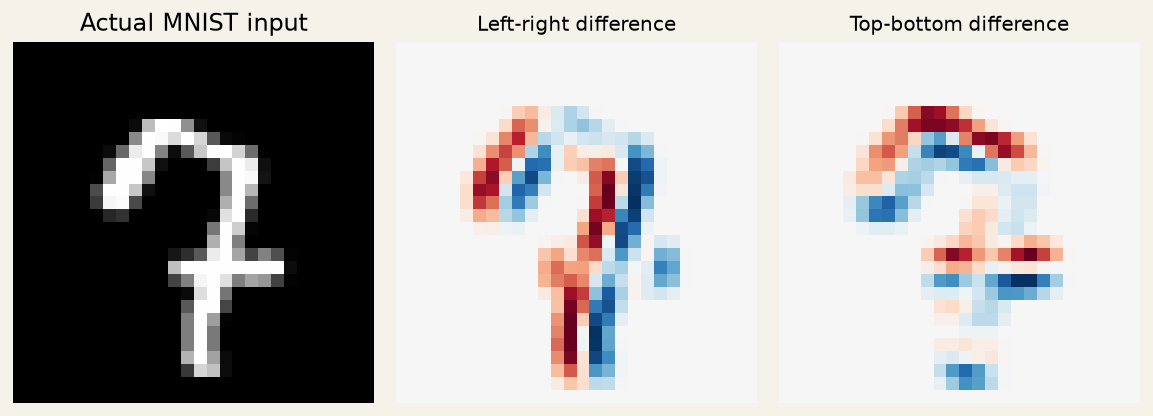

In [6]:
manual_filter_figure(data,SAMPLE); plt.show()

## 4. 단어를 모델 구조와 연결하기
같은 필터를 여러 위치에 쓰는 **공유**, 반응 지도의 축인 **채널**, 음수 반응을0으로 만드는 **ReLU**, 작은 영역의 대표값을 남기는 **pooling**을 연결합니다.
아래에서는 이미지 크기와 채널 수가 어떻게 변하는지 관찰하세요. 출력10개는 숫자 후보0–9의 점수입니다.

In [7]:
shape_model=DigitCNN()
x=data['x_train'][:1]
print('input',tuple(x.shape))
with torch.no_grad():
    for layer in shape_model.features:
        x=layer(x); print(type(layer).__name__,tuple(x.shape))
    print('class scores',tuple(shape_model.classifier(x.flatten(1)).shape))
print('파라미터 수:',sum(p.numel() for p in shape_model.parameters()))
assert sum(p.numel() for p in shape_model.parameters())==9098
print('ReLU 예제:',F.relu(torch.tensor([-2.,0.,3.])).tolist())
print('2x2 max:',float(F.max_pool2d(torch.tensor([[[[1.,4.],[2.,3.]]]]),2).item()))

input (1, 1, 28, 28)
Conv2d (1, 8, 28, 28)
ReLU (1, 8, 28, 28)
MaxPool2d (1, 8, 14, 14)
Conv2d (1, 16, 14, 14)
ReLU (1, 16, 14, 14)
MaxPool2d (1, 16, 7, 7)
class scores (1, 10)
파라미터 수: 9098
ReLU 예제: [0.0, 0.0, 3.0]
2x2 max: 4.0


## 5. 예측 → 손실 → 변화율 → 수정
**예상:** 학습 전에 10개 후보의 정답을 잘 고를 수 있을까요? 같은 정확도라도 정답 점수가 달라지면 손실이 달라질까요?
매 호출마다 새 모델을 같은 seed로 초기화합니다. validation은 관찰용이며 미리 정한 최종epoch를 사용합니다.

epoch 1/6: train CE 1.322, val accuracy 0.822


epoch 2/6: train CE 0.375, val accuracy 0.896
epoch 3/6: train CE 0.255, val accuracy 0.914


epoch 4/6: train CE 0.185, val accuracy 0.940
epoch 5/6: train CE 0.138, val accuracy 0.927


epoch 6/6: train CE 0.116, val accuracy 0.954
Training: 1.2s / CPU


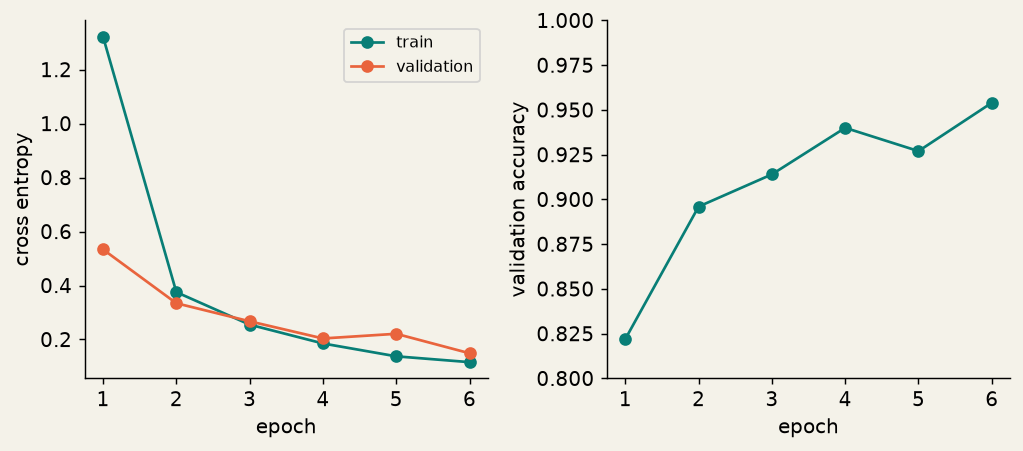

In [8]:
model,history,initial_weights=fit_digit(data,EPOCHS,SEED)
history_figure(history); plt.show()

## 6. 한 장의 점수와 전체 정확도 구분
**logits**는 클래스별 점수, **softmax**는 합이1인 상대적 출력입니다. 그 값이 실제 정답률과 자동으로 같지는 않습니다.
test는 고정1,000장 부분집합입니다. 공식test10,000장 전체 벤치마크 성능이라고 쓰지 마세요.

고정 test 1000장: accuracy=0.953, CE=0.127


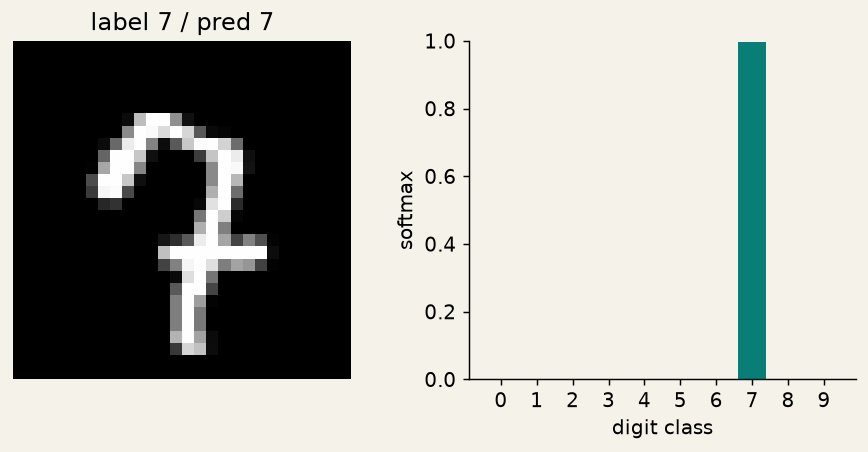

In [9]:
test_result=evaluate_digit(model,data['x_test'],data['y_test'])
print(f"고정 test {len(data['y_test'])}장: accuracy={test_result['accuracy']:.3f}, CE={test_result['ce']:.3f}")
prediction_figure(data,test_result,SAMPLE); plt.show()

## 7. 사람의 단서로 오류를 관찰하기
아래는 실제 오분류 중 앞6장입니다. 전체test의 대표 표본이 아닙니다.
**활동:** 한 장을 골라 애매한 획을 말하고, 필터·특징 맵·수용 영역 중 두 용어로 확인할 가설을 적으세요.
그림만으로 “이 뉴런 때문에 틀렸다”고 원인을 확정하지 않습니다.

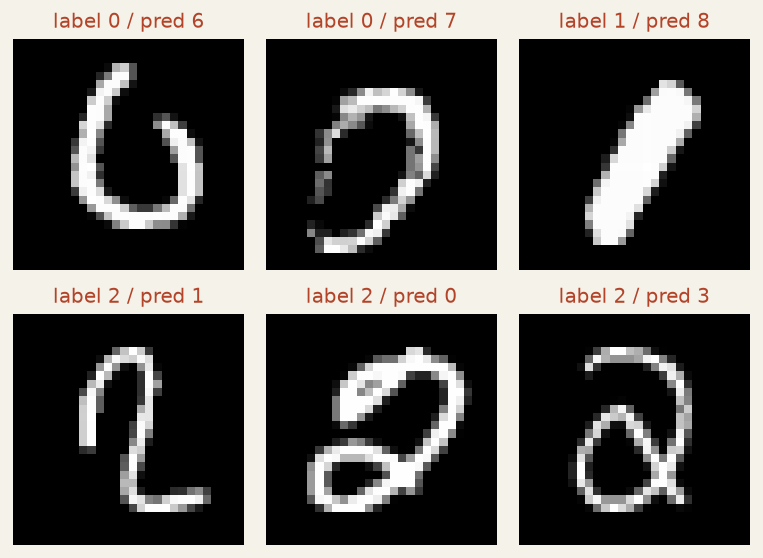

실제 오분류 예시


In [10]:
fig,error_ids,are_errors=errors_figure(data,test_result); plt.show()
print('실제 오분류 예시' if are_errors else '이번 실행에는 오분류가 없어 정상 예시를 표시했습니다.')

## 8. 특징 맵과 입력 변환 · 선택 확장
학습된 첫 층의 반응8장을 봅니다. 채널 이름은 번호이며 자동으로 “고리 뉴런” 같은 의미를 붙이지 않습니다.
같은 모델에 위치 이동이나 가림을 적용하고 원본과 비교합니다. 이동에는 반대편으로 감기는 wrap-around를 쓰지 않습니다.

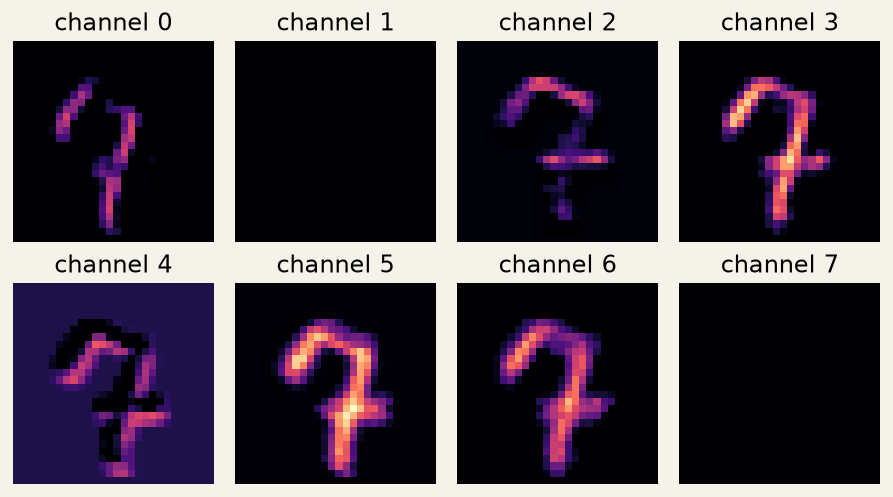

원본 정확도 0.953 이동 후 0.686
공유 필터를 사용해도 최종 분류의 완전한 이동 불변성이 보장되지는 않습니다.


In [11]:
feature_figure(model,data,SAMPLE); plt.show()
SHIFT=3  # 0~6, 오른쪽 이동
assert SHIFT in range(7)
shifted=torch.zeros_like(data['x_test'])
if SHIFT:shifted[...,SHIFT:]=data['x_test'][...,:-SHIFT]
else:shifted=data['x_test'].clone()
shift_result=evaluate_digit(model,shifted,data['y_test'])
print('원본 정확도',round(test_result['accuracy'],3),'이동 후',round(shift_result['accuracy'],3))
print('공유 필터를 사용해도 최종 분류의 완전한 이동 불변성이 보장되지는 않습니다.')

## 9. 관찰 네 문장 저장
설정과 측정값은 자동으로 기록됩니다. 아래 네 문장을 본인 관찰로 바꾸고 실행하세요.
Colab 파일 목록에서 JSON이나 출력이 담긴 ipynb를 내려받아 보관합니다.

In [12]:
reflection={'과제':'이 노트북의 출력이 분류/검출/분할 중 무엇인지 근거와 함께 작성하세요.',
    '비유와 연산':'필터 또는 특징 맵을 사람의 비유와 실제 연산으로 각각 설명하세요.',
    '관찰':'실제 정확도 또는 오류 이미지의 구체적인 획을 인용하세요.',
    '한계':'다음에 시험할 입력 변화와 이 결과로 아직 말할 수 없는 것을 적으세요.'}
metrics=experiment_metrics(data,model,history,test_result,EPOCHS,SEED)
metrics.update(shift=SHIFT,shift_accuracy=shift_result['accuracy'])
out=Path('outputs/week01_mnist');out.mkdir(parents=True,exist_ok=True)
(out/'observations.json').write_text(json.dumps({'metrics':metrics,'reflection':reflection},ensure_ascii=False,indent=2),encoding='utf-8')
print('저장:',out/'observations.json')
for k,v in reflection.items():print(k+':',v)

저장: outputs\week01_mnist\observations.json
과제: 이 노트북의 출력이 분류/검출/분할 중 무엇인지 근거와 함께 작성하세요.
비유와 연산: 필터 또는 특징 맵을 사람의 비유와 실제 연산으로 각각 설명하세요.
관찰: 실제 정확도 또는 오류 이미지의 구체적인 획을 인용하세요.
한계: 다음에 시험할 입력 변화와 이 결과로 아직 말할 수 없는 것을 적으세요.


### 자율 실험과 해설 방향
1. **필터:** COL을0과2로 비교합니다. 모두 밝아도 좌우 차이가 없으면 0이 되는 이유를 설명하세요.
2. **입력 변화:** SHIFT를0·2·4로 비교합니다. 0은 원본과 같은 결과여야 합니다. 8절만 재실행합니다.
3. **학습:** EPOCHS를2와6으로 바꾸고5절부터 실행합니다. 비교 설정은 test로 선택하지 않고 validation으로 검토하세요.

정확도는 실제 관측값을 적습니다. test를 본 뒤 바꾼 설정은 탐색으로 표시하고 최종 주장은 별도 보류 데이터로 확인합니다.
사람과 같은 숫자를 맞혔다고 같은 내부 처리·경험·맥락을 사용했다고 결론 내리지 않습니다.

출처: [MNIST 구성](https://www.tensorflow.org/datasets/catalog/mnist),
[Torchvision 공식 MNIST 미러·체크섬](https://docs.pytorch.org/vision/stable/_modules/torchvision/datasets/mnist.html),
[분류·검출·분할 과제](https://docs.pytorch.org/vision/stable/models.html).
원 데이터는 LeCun·Cortes·Burges의 MNIST입니다. FashionMNIST·인쇄 글꼴·수업용 합성 도형과 구분합니다.